## Lab 1: Data Preparation for Amazon Nova Fine-tuning

**⏱️ Estimated completion time: 10 minutes**

### Lab overview

Brief: This lab demonstrates the complete data preparation pipeline for fine-tuning Amazon Nova models on visual question-answering tasks. You'll transform raw DocumentVQA data into Bedrock-compatible format, upload to S3, and prepare the foundation for model training.

Expected outputs: Properly formatted training, validation, and test datasets uploaded to S3 in Bedrock conversation format, ready for Nova fine-tuning in subsequent labs.

**Key Learning Objectives:**
- Master Amazon Nova's data format requirements and constraints
- Understand the DocumentVQA dataset structure and visual QA tasks
- Experience the complete data pipeline from raw data to training-ready format
- Explore AWS S3 integration for large-scale ML data management



### 🎯 Workshop Context

In this builder session, you'll work with real-world document understanding challenges. The [DocumentVQA](https://huggingface.co/datasets/HuggingFaceM4/DocumentVQA) dataset contains diverse document types - forms, charts, tables, and text documents - paired with natural language questions and answers.

**Why DocumentVQA?**
- **Real-world relevance**: Document processing is a common enterprise AI use case
- **Multimodal complexity**: Requires understanding both visual layout and textual content
- **Scalable applications**: From invoice processing to research document analysis
- **Nova's strength**: Amazon Nova excels at visual understanding tasks

**What makes this challenging?**
- Documents have complex layouts with tables, charts, and mixed content
- Questions require spatial reasoning ("What's in the top-right corner?")
- Answers may require synthesis across multiple document elements
- Model must understand document structure and visual hierarchy

### 1 — Environment setup and package installation

Brief: Install and configure the required Python packages for Amazon Nova data preparation. This includes AWS SDKs, image processing libraries, and data manipulation tools.

Why we're doing this: Nova fine-tuning requires specific data formats and S3 integration. These packages provide the foundation for data preprocessing, visualization, and AWS service interaction.

What to check after running: Verify all packages install successfully without errors. You may need to restart the kernel after installation.

References: 
- [SageMaker Python SDK Documentation](https://sagemaker.readthedocs.io/)
- [Pillow Documentation](https://pillow.readthedocs.io/)
- [Matplotlib Documentation](https://matplotlib.org/)

⚠️ Note: 

Please select the following **Python Environment** to run this notebook.

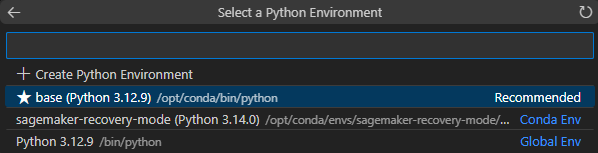

In [ ]:
# Install and upgrade required packages for the data preparation pipeline
# sagemaker: AWS SageMaker SDK for machine learning workflows and S3 integration
# datasets: Hugging Face datasets library for loading and processing ML datasets 
%pip install sagemaker==2.254.1
# %pip install datasets # (Optional, in case you want to download the entire HuggingFace dataset. For this workshop we have already downloaded a subset of the dataset!)

# Install additional packages for image processing and visualization
# pillow: Python Imaging Library for image manipulation and format conversion
# matplotlib: Plotting library for data visualization and sample inspection
%pip install pillow matplotlib 

⚠️ Note: You need to restart the kernel to use updated packages.

## Understanding Amazon Nova Data Requirements

### Questions to Consider:
1. What is the minimum recommended number of samples for fine-tuning?
2. What file format is required for training data?
3. What are the supported roles in the conversation format?
4. Where must images be stored for Amazon SageMaker AI access?

**Your Task:** Read through to understand data requirements. 

---

### Amazon Nova Understanding Model Data Requirements

**Minimum Data Size:**
- At least **100 samples** for each task you want the model to learn
- More complex tasks may require additional data

**File Format:**
- Training and validation datasets must be **JSONL files**
- Each line contains a JSON object representing one training record
- File names: alphanumeric characters, underscores, hyphens, slashes, and dots only

**Image Constraints:**
- Dataset cannot mix media modalities (images OR videos, not both)
- Multiple images per sample are supported
- Images must be accessible to Amazon SageMaker AI via S3
- Images must be in the same S3 bucket as your dataset

**Conversation Format:**
- Supported roles: `user` and `assistant`
- First message must have `role: user`
- Last message must have `role: assistant`
- Optional system prompt can be included

📖 **Reference:** [Amazon Nova Fine-tuning Documentation](https://docs.aws.amazon.com/nova/latest/userguide/fine-tune-prepare-data-understanding.html)

---



### 2 — Import core libraries for data processing

Brief: Import essential Python libraries for data manipulation, file operations, and AWS service integration. These libraries form the foundation for our data preprocessing pipeline.

Why we're doing this: Each library serves a specific purpose in our data pipeline - from basic file operations to AWS-specific functionality. Understanding these dependencies helps you build robust data processing workflows.

What to check after running: Verify all imports execute without errors. If you encounter import errors, ensure all packages from Step 1 were installed correctly.

In [ ]:
# Import necessary libraries for data processing and handling
import os          # Operating system interface for file operations and path manipulation
import json        # JSON encoder and decoder for data serialization and JSONL processing
import base64      # Base64 encoding/decoding for binary data (useful for image encoding)
from io import BytesIO  # In-memory binary streams for efficient data handling

## Exploring the DocumentVQA Dataset

**Your Task:** Learn about the DocumentVQA dataset and examine its structure.

### About DocumentVQA Dataset

We're using the **HuggingFace DocumentVQA dataset** for this workshop:
- **Source:** [HuggingFaceM4/DocumentVQA](https://huggingface.co/datasets/HuggingFaceM4/DocumentVQA)
- **Task:** Visual Question Answering on document images
- **Format:** Images paired with question-answer pairs

### Dataset Statistics
- **Training samples:** ~39,000 samples
- **Validation samples:** ~5,000 samples
- **Test samples:** ~5,000 samples
- **Image types:** Document pages, forms, charts, tables


### Pre-downloaded Dataset

To save time, we've already downloaded a subset of the DocVQA dataset from the HuggingFace Hub using load_dataset() function:

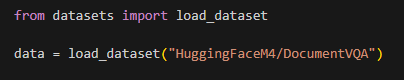

📁 **Dataset Location:** `./HuggingFace_DocVQA/`
- **Images:** There are 100 `.jpg` files containing document images
- **Metadata:** `metadata.jsonl` file with question-answer pairs

### Dataset Structure

Each record in `metadata.jsonl` contains:
- `file_name`: Image filename
- `prompt`: Question about the document
- `completion`: Answer to the question

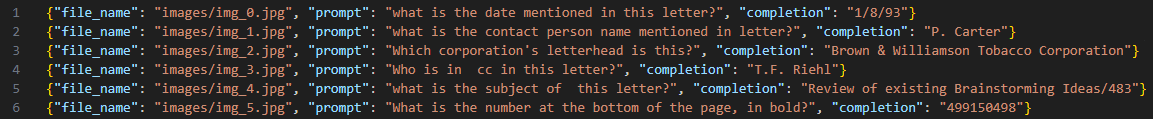

**💡 Objective :** This format needs to be converted to Amazon Nova's required JSONL format with conversation structure.

### 3 — Visual data exploration and sample inspection

Brief: Create and use visualization functions to inspect DocumentVQA samples. This hands-on exploration helps you understand the data characteristics and quality before preprocessing.

Why we're doing this: Visual inspection is crucial for understanding multimodal datasets. You need to see the actual document images and their associated questions to appreciate the complexity of the task and identify potential data quality issues.

What to check after running: Examine the document types, question complexity, and answer formats. Look for patterns that might affect training.

**🔍 Exploration Tasks:**
1. **Document Analysis**: What types of documents do you observe? (forms, invoices, charts, etc.)
2. **Question Complexity**: Are questions simple factual queries or do they require reasoning?
3. **Answer Patterns**: What types of answers are expected? (short phrases, numbers, yes/no)
4. **Quality Assessment**: Do you notice any potential data quality issues?

In [ ]:
# Import additional libraries for data visualization and sample display
from PIL import Image         # Python Imaging Library for image processing
import random                 # Random sampling for data visualization
import matplotlib.pyplot as plt  # Plotting library for visualization

def display_docvqa_samples(data_dir="./HuggingFace_DocVQA", num_samples=4, randomize=True):
    """
    Display DocVQA samples with images and their corresponding question-answer pairs.
    
    This function visualizes document images alongside their associated questions and answers
    from the DocVQA dataset in a side-by-side layout for easy inspection.
    
    Args:
        data_dir (str): Path to the directory containing DocVQA data
        num_samples (int): Number of samples to display
        randomize (bool): Whether to randomly sample or take first n samples
    """
    # Load metadata containing question-answer pairs
    metadata_path = os.path.join(data_dir, "metadata.jsonl")
    
    # Read all samples from the JSONL metadata file
    all_samples = []
    with open(metadata_path, 'r') as f:
        for line in f:
            all_samples.append(json.loads(line.strip()))
    
    # Select samples based on randomization preference
    if randomize:
        samples = random.sample(all_samples, min(num_samples, len(all_samples)))
    else:
        samples = all_samples[:num_samples]
    
    # Display each sample with image and QA pair
    for i, sample in enumerate(samples):
        # Load and process the image
        img_path = os.path.join(data_dir, sample["file_name"])
        image = Image.open(img_path)
        
        # Ensure image is in RGB format for consistent display
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Create figure with side-by-side layout
        plt.figure(figsize=(15, 8))
        
        # Display the document image on the left
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.axis('off')  # Remove axes for cleaner display
        plt.title('Input Image')
        
        # Display the question-answer pair on the right
        plt.subplot(1, 2, 2)
        plt.axis('off')  # Remove axes for text display
        text_content = f"Question:\n{sample['prompt']}\n\nAnswer:\n{sample['completion']}"
        plt.text(0, 0.5, text_content, fontsize=10, wrap=True, verticalalignment='center')
        
        plt.tight_layout()
        plt.show()


In [ ]:
# Now lets visualize random images and their Question-Answer pairs to explore the dataset 
display_docvqa_samples(num_samples=3, randomize=True)

### 4 — Understanding Bedrock conversation format requirements

Brief: Learn the specific JSONL format required by Amazon Bedrock for Nova fine-tuning. This format structures data as conversations with proper schema versioning and S3 references.

Why we're doing this: Bedrock requires a specific conversation format that differs from typical ML datasets. Understanding this format is essential for successful data preparation and ensures compatibility with Nova's training pipeline.

### Required Bedrock Conversation Format

Amazon Nova fine-tuning requires data in a specific conversation format with S3-hosted images:

**Key Requirements:**
- **S3 Storage**: Images must be accessible via S3 URIs
- **Conversation Structure**: User-assistant message pairs


**Detailed guidelines and requirements:** [Amazon Nova Fine-tuning Data Format](https://docs.aws.amazon.com/nova/latest/userguide/fine-tune-prepare-data-understanding.html)

The following example is for custom fine tuning over text and a single image.

```json
//train.jsonl
{
    "schemaVersion": "bedrock-conversation-2024",
    "system": [{
        "text": "You are a smart assistant that answers questions respectfully"
    }],
    "messages": [{
            "role": "user",
            "content": [{
                    "text": "What is the total amount on this invoice?"
                },
                {
                    "image": {
                        "format": "jpeg",
                        "source": {
                            "s3Location": {
                                "uri": "s3://your-bucket/docvqa/train/invoice_001.jpg",
                                "bucketOwner": "123456789012"
                            }
                        }
                    }
                }
            ]
        },
        {
            "role": "assistant",
            "content": [{
                "text": "The total amount is $1,234.56"
            }]
        }
    ]
}
```

**Format Benefits:**
- **Structured Conversations**: Mirrors natural interaction patterns
- **Multimodal Support**: Seamlessly combines text and images
- **Scalability**: S3 integration supports large-scale datasets
- **Versioning**: Schema versioning ensures compatibility

### 5 — Configure AWS environment and extract S3 parameters

Brief: Set up AWS session context and extract the S3 bucket information needed for dataset upload and Bedrock format conversion. 

Why we're doing this: Nova fine-tuning requires data to be stored in S3 with specific URI formats. We need to determine our S3 bucket name, account ID, and region to properly format the dataset references.

What to check after running: Verify that bucket name, account ID, and region are correctly extracted. These values will be embedded in our training data.

In [ ]:
# Extract S3 bucket, prefix, and account ID needed for Bedrock format conversion

import sagemaker
import boto3

# Get SageMaker execution role (handles both SageMaker Studio and notebook instances)
try:
    role = sagemaker.get_execution_role()
except ValueError:
    # Fallback for local development environments
    iam = boto3.client("iam")
    role = iam.get_role(RoleName="sagemaker_execution_role")["Role"]["Arn"]

# Initialize SageMaker session to access AWS account information
sess = sagemaker.Session()
bucket_name = sess.default_bucket()  # SageMaker default bucket for this account/region
region = sess.boto_region_name       # Current AWS region
default_prefix = sess.default_bucket_prefix  # Default prefix for SageMaker resources
my_prefix = "docvqa"                # Custom prefix for our DocumentVQA dataset
account_id = sess.account_id()       # AWS account ID (required for S3 bucket owner field)

# Display the extracted configuration
print(f"AWS Configuration:")
print(f"  S3 Bucket: {bucket_name}")
print(f"  Region: {region}")
print(f"  Dataset Prefix: {my_prefix}")
print(f"  Account ID: {account_id}")
print(f"\n📁 Data will be stored at: s3://{bucket_name}/{my_prefix}/")

### 6 — Implement dataset preprocessing and format conversion

Brief: Create a comprehensive function to split the DocumentVQA dataset into train/validation/test sets and convert each sample to Bedrock's conversation format. This function handles both data organization and format transformation.

Why we're doing this: This is the core data preprocessing step that transforms our raw DocumentVQA data into the exact format required by Nova fine-tuning. The function handles data splitting, format conversion, and file organization in one streamlined process.


In [ ]:
# Comprehensive dataset preprocessing function
# Splits HuggingFace_DocVQA into train/validation/test and converts to Bedrock format

import os
import shutil
import json
import random
from pathlib import Path
import logging

def prep_dataset(source_image_dir, source_jsonl_file, output_base_dir, splits):
    """
    Split dataset into train, validation and test sets while converting to Bedrock format.
    
    This function performs multiple operations:
    1. Reads the source DocumentVQA dataset
    2. Randomly shuffles and splits data into train/val/test
    3. Converts each sample to Bedrock conversation format
    4. Copies images to appropriate directories
    5. Generates JSONL files with S3 references
    
    Args:
        source_image_dir (str): Directory containing source images
        source_jsonl_file (str): Path to source JSONL metadata file
        output_base_dir (str): Base directory for organized output
        splits (tuple): Number of samples for (train, val, test) splits
    """
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger(__name__)
    
    try:
        # Create main output directory structure
        base_dir = Path(output_base_dir)
        base_dir.mkdir(exist_ok=True, parents=True)
        
        # Create subdirectories for each data split
        subdirs = ['train', 'validation', 'test']
        for subdir in subdirs:
            (base_dir / subdir).mkdir(exist_ok=True)
        
        # Read and parse the source JSONL metadata file
        logger.info(f"Reading JSONL file: {source_jsonl_file}")
        with open(source_jsonl_file, 'r') as f:
            dataset = [json.loads(line) for line in f]
        
        # Shuffle dataset to ensure random distribution across splits
        random.shuffle(dataset)
        logger.info(f"Loaded and shuffled {len(dataset)} samples")
        
        # Split dataset according to specified sample counts
        train_data = dataset[:splits[0]]
        val_data = dataset[splits[0]:splits[0]+splits[1]]
        test_data = dataset[splits[0]+splits[1]:splits[0]+splits[1]+splits[2]]
        
        split_data = {
            'train': train_data,
            'validation': val_data,
            'test': test_data
        }
        
        # Process each split: copy images and convert format
        for split_name, entries in split_data.items():
            split_dir = base_dir / split_name
            output_jsonl = []
            
            logger.info(f"Processing {split_name} split with {len(entries)} samples")
            
            for entry in entries:
                # Extract image filename and set up paths
                image_filename = os.path.basename(entry['file_name'])
                src_path = Path(source_image_dir) / image_filename
                dst_path = split_dir / image_filename
                
                # Copy image file if it exists
                if src_path.exists():
                    shutil.copy2(src_path, dst_path)
                else:
                    logger.warning(f"Image not found: {src_path}")
                    continue
                
                # Convert to Bedrock conversation format
                # This transforms simple prompt-completion pairs into structured conversations
                new_entry = {
                    "schemaVersion": "bedrock-conversation-2024",
                    "system": [{
                        "text": "You are a smart assistant that answers questions respectfully"
                    }],
                    "messages": [{
                        "role": "user",
                        "content": [{
                            "text": entry['prompt']  # Original question
                        },
                        {
                            "image": {
                                "format": "jpeg",
                                "source": {
                                    "s3Location": {
                                        # Construct S3 URI for the image
                                        "uri": f"s3://{bucket_name}/{my_prefix}/{split_name}/{image_filename}",
                                        "bucketOwner": account_id
                                    }
                                }
                            }
                        }]
                    },
                    {
                        "role": "assistant",
                        "content": [{
                            "text": entry['completion']  # Original answer
                        }]
                    }]
                }
                output_jsonl.append(new_entry)
            
            # Write JSONL file for this split
            output_file = split_dir / f"{split_name}.jsonl"
            with open(output_file, 'w') as f:
                for entry in output_jsonl:
                    f.write(json.dumps(entry) + '\n')
            
            logger.info(f"{split_name}: {len(output_jsonl)} entries processed and saved")
        
        logger.info(f"Dataset preprocessing complete! Output directory: {output_base_dir}")
        
    except Exception as e:
        logger.error(f"Error processing dataset: {str(e)}")
        raise


### 7 — Execute dataset preprocessing with defined parameters

Brief: Run the dataset preprocessing function with specific parameters to create train/validation/test splits. This execution transforms our raw DocumentVQA data into Nova-ready format.

Why we're doing this: This step executes the actual data transformation. We're using a 60/20/20 split to ensure sufficient training data while maintaining proper validation and test sets for model evaluation.

What to check after running: Verify that the function completes successfully and creates the expected directory structure with converted JSONL files.

**🔍 Exploration Task**: After execution, examine the generated files. How does the output structure differ from the input? What are the key transformations applied?

In [ ]:
# Define dataset preprocessing parameters
source_image_dir = "./HuggingFace_DocVQA/images"      # Input: Original DocumentVQA images
source_jsonl_file = "./HuggingFace_DocVQA/metadata.jsonl"  # Input: Original metadata
output_base_dir = "Nova_DocVQA_local"                # Output: Organized dataset directory

# Define data split sizes (optimized for workshop timing)
train_size, val_size, test_size = 60, 20, 20

print(f"Dataset Split Configuration:")
print(f"  Training samples: {train_size}")
print(f"  Validation samples: {val_size}")
print(f"  Test samples: {test_size}")
print(f"  Total samples: {train_size + val_size + test_size}")
print(f"\n🚀 Starting dataset preprocessing...")

# Execute the dataset preprocessing
prep_dataset(source_image_dir, source_jsonl_file, output_base_dir, splits=(train_size, val_size, test_size))

print(f"\n✅ Dataset preprocessing completed successfully!")
print(f"📁 Processed data available in: {output_base_dir}/")

### 8 — Implement S3 upload functionality for training data

Brief: Create a robust S3 upload function to transfer the processed dataset from local storage to S3. This function handles parallel uploads, error handling, and verification to ensure data integrity.

Why we're doing this: Nova fine-tuning requires data to be accessible via S3. This upload process makes our processed dataset available to the SageMaker training service while maintaining the directory structure and file organization.

In [ ]:
import boto3
import os
from pathlib import Path
import logging
from concurrent.futures import ThreadPoolExecutor
from botocore.exceptions import ClientError

def upload_to_s3(local_dir, bucket_name, s3_prefix):
    """
    Upload local dataset directories to S3.
    
    Args:
        local_dir (str): Local directory containing train/validation/test folders
        bucket_name (str): Name of the S3 bucket
        s3_prefix (str): S3 prefix (folder path) where files will be uploaded
    """
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger(__name__)
    
    # Initialize S3 client
    s3_client = boto3.client('s3')
    
    def upload_file(local_path, s3_key):
        """Helper function to upload a single file"""
        try:
            s3_client.upload_file(
                str(local_path),
                bucket_name,
                s3_key
            )
            return True
        except ClientError as e:
            logger.error(f"Error uploading {local_path}: {str(e)}")
            return False

    try:
        local_base = Path(local_dir)
        
        # Verify local directory exists
        if not local_base.exists():
            raise ValueError(f"Local directory not found: {local_dir}")
            
        # Get list of all files to upload
        upload_tasks = []
        
        for split in ['train', 'validation', 'test']:
            split_dir = local_base / split
            if not split_dir.exists():
                logger.warning(f"Split directory not found: {split_dir}")
                continue
                
            # Process all files in the split directory
            for file_path in split_dir.glob('**/*'):
                if file_path.is_file():
                    # Calculate relative path for S3 key
                    relative_path = file_path.relative_to(local_base)
                    s3_key = f"{s3_prefix}/{relative_path}"
                    
                    upload_tasks.append((file_path, s3_key))
        
        # Upload files using thread pool for parallel processing
        total_files = len(upload_tasks)
        successful_uploads = 0
        
        logger.info(f"Starting upload of {total_files} files to s3://{bucket_name}/{s3_prefix}")
        
        with ThreadPoolExecutor(max_workers=10) as executor:
            for file_path, s3_key in upload_tasks:
                logger.info(f"Uploading {file_path} to s3://{bucket_name}/{s3_key}")
                if upload_file(file_path, s3_key):
                    successful_uploads += 1
                    
        logger.info(f"Upload complete. Successfully uploaded {successful_uploads} of {total_files} files")
        
        # Verify uploads
        for split in ['train', 'validation', 'test']:
            try:
                # Check if JSONL file exists in S3
                s3_client.head_object(
                    Bucket=bucket_name,
                    Key=f"{s3_prefix}/{split}/{split}.jsonl"
                )
                logger.info(f"Verified {split}.jsonl exists in S3")
            except ClientError as e:
                logger.warning(f"Could not verify {split}.jsonl in S3: {str(e)}")
                
    except Exception as e:
        logger.error(f"Error during upload: {str(e)}")
        raise


In [ ]:
local_dataset_dir = "Nova_DocVQA_local"
s3_prefix = "docvqa"
upload_to_s3(local_dataset_dir, bucket_name, s3_prefix)

### We also need to create two S3 sub directories to store the training output and Tensorboard logs.

In [ ]:
import boto3
from botocore.exceptions import ClientError
import logging

def create_s3_directories():
    """
    Create output and tensorboard directories in S3
    """
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger(__name__)
    
    # S3 configuration
    directories = [
        f"{s3_prefix}/output/",
        f"{s3_prefix}/tensorboard/"
    ]
    
    # Initialize S3 client
    s3_client = boto3.client('s3')
    
    try:
        # Check if bucket exists
        try:
            s3_client.head_bucket(Bucket=bucket_name)
            logger.info(f"Bucket {bucket_name} exists")
        except ClientError as e:
            error_code = int(e.response['Error']['Code'])
            if error_code == 404:
                logger.error(f"Bucket {bucket_name} does not exist")
                raise
            else:
                raise
        
        created_paths = []
        # Create directories
        for directory_path in directories:
            try:
                # Create an empty placeholder file to establish the directory
                placeholder_key = f"{directory_path}.placeholder"
                s3_client.put_object(
                    Bucket=bucket_name,
                    Key=placeholder_key,
                    Body=""
                )
                
                full_path = f"s3://{bucket_name}/{directory_path}"
                created_paths.append(full_path)
                logger.info(f"Successfully created directory: {full_path}")
                
            except Exception as e:
                logger.error(f"Error creating directory {directory_path}: {str(e)}")
                raise
        
        return created_paths
        
    except Exception as e:
        logger.error(f"Error in create_s3_directories: {str(e)}")
        raise

# Create the directories
try:
    created_paths = create_s3_directories()
    print("\nCreated directories:")
    for path in created_paths:
        print(f"- {path}")
except Exception as e:
    print(f"Failed to create directories: {str(e)}")


### Store these vars for reuse in subsequent notebooks

In [ ]:
train_dataset_s3_path = f"s3://{bucket_name}/{s3_prefix}/train/train.jsonl"
val_dataset_s3_path = f"s3://{bucket_name}/{s3_prefix}/validation/validation.jsonl"
test_dataset_s3_path = f"s3://{bucket_name}/{s3_prefix}/test/test.jsonl"
output = f"s3://{bucket_name}/{s3_prefix}/output/"
tensorboard = f"s3://{bucket_name}/{s3_prefix}/tensorboard/"

In [ ]:
%store train_dataset_s3_path val_dataset_s3_path test_dataset_s3_path output tensorboard

## 🎉 Lab 1 Complete!

**Congratulations!** You have successfully completed the data preparation pipeline for Amazon Nova fine-tuning. Here's what you accomplished:

### ✅ Tasks Completed:
1. **Environment Setup** - Installed required packages and dependencies
2. **Requirements Analysis** - Learned Nova's data format requirements and constraints
3. **Dataset Exploration** - Examined DocumentVQA structure and sample data
4. **Data Visualization** - Created functions to inspect document images and QA pairs
5. **Format Conversion** - Transformed data from simple format to Bedrock conversation schema
6. **AWS Integration** - Configured S3 storage and account parameters
7. **Data Processing** - Split dataset into train/validation/test with proper organization
8. **S3 Upload** - Transferred processed data to S3 for training access
9. **Infrastructure Setup** - Created S3 directories for training outputs and logs

### 📁 Key Outputs:
- **Processed Dataset**: 100 samples split into 60/20/20 train/val/test
- **Bedrock Format**: All data converted to conversation schema with S3 references
- **S3 Storage**: Complete dataset uploaded and organized in cloud storage
- **Training Infrastructure**: Output and tensorboard directories prepared
- **Stored Variables**: S3 paths and configuration saved for next notebook

### 🚀 Next Step:
- **Model Training**: Use the prepared data for Nova fine-tuning

### **Ready for training? Proceed to Lab 2!**